In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

sns.set(rc={'figure.figsize': [10, 5]}, font_scale=1.3)
%matplotlib inline


In [3]:
df = pd.read_csv("googleplaystore.csv")
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


#### geting basic info about data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


##### Drop dubplicates

In [5]:
df.duplicated().sum()

483

In [6]:
df.drop_duplicates(inplace= True)
df.reset_index(drop=True,inplace=True)

In [7]:
df['App'].value_counts()

App
ROBLOX                                           9
8 Ball Pool                                      7
Bubble Shooter                                   6
Helix Jump                                       6
Zombie Catchers                                  6
                                                ..
Theme Android P Black design for LG V30          1
Popsicle Launcher for Android P 9.0 launcher     1
PixelLab - Text on pictures                      1
P Launcher for Android™ 9.0                      1
iHoroscope - 2018 Daily Horoscope & Astrology    1
Name: count, Length: 9660, dtype: int64

In [8]:
df[df['App']=="ROBLOX"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1446,ROBLOX,GAME,4.5,4447388,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1494,ROBLOX,GAME,4.5,4447346,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1538,ROBLOX,GAME,4.5,4448791,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1625,ROBLOX,GAME,4.5,4449882,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1653,ROBLOX,GAME,4.5,4449910,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1786,ROBLOX,FAMILY,4.5,4449910,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1857,ROBLOX,FAMILY,4.5,4450855,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1956,ROBLOX,FAMILY,4.5,4450890,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
4072,ROBLOX,FAMILY,4.5,4443407,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up


In [9]:
df.drop("Reviews",axis=1).duplicated().sum()

575

In [10]:
index_droped=df[df.drop("Reviews",axis=1).duplicated()].index
index_droped

Index([  260,   261,   262,   348,   349,   351,   352,   356,   358,   359,
       ...
        9721,  9731,  9787,  9845, 10164, 10165, 10233, 10238, 10248, 10271],
      dtype='int64', length=575)

In [11]:
df.drop(index_droped,axis=0,inplace=True)


In [12]:
df.reset_index(drop=True,inplace=True)

In [13]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9778,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
9779,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
9780,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
9781,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [14]:
df['App'].value_counts().head(30)

App
Solitaire                                           3
Duolingo: Learn Languages Free                      3
Bubble Shooter                                      3
Video Editor                                        3
Clash of Clans                                      2
Dungeon Hunter Champions: Epic Online Action RPG    2
Uber                                                2
TED                                                 2
Ruler                                               2
Colorfy: Coloring Book for Adults - Free            2
Pou                                                 2
Red Bull TV: Live Sports, Music & Entertainment     2
Clash Royale                                        2
Princess Coloring Book                              2
Hello Kitty Nail Salon                              2
letgo: Buy & Sell Used Stuff, Cars & Real Estate    2
Plants vs. Zombies FREE                             2
Word Search                                         2
Candy Crush Saga        

In [15]:
df[df["App"]=='Duolingo: Learn Languages Free']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
573,Duolingo: Learn Languages Free,EDUCATION,4.7,6289924,Varies with device,"100,000,000+",Free,0,Everyone,Education;Education,"August 1, 2018",Varies with device,Varies with device
1620,Duolingo: Learn Languages Free,FAMILY,4.7,6294400,Varies with device,"100,000,000+",Free,0,Everyone,Education;Education,"August 1, 2018",Varies with device,Varies with device
7454,Duolingo: Learn Languages Free,FAMILY,4.7,6297590,Varies with device,"100,000,000+",Free,0,Everyone,Education;Education,"August 6, 2018",Varies with device,Varies with device


In [16]:
df[df['App'] == 'Solitaire']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1359,Solitaire,GAME,4.7,254258,23M,"10,000,000+",Free,0,Everyone,Card,"August 1, 2018",2.137.0,4.1 and up
1560,Solitaire,GAME,4.7,154264,12M,"10,000,000+",Free,0,Everyone,Card,"June 8, 2018",Varies with device,Varies with device
1588,Solitaire,FAMILY,4.4,685,26M,"100,000+",Free,0,Everyone,Card;Brain Games,"July 16, 2018",1.7.101,4.1 and up


In [17]:
df[df['App'] == 'Bubble Shooter']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1360,Bubble Shooter,GAME,4.5,148897,46M,"10,000,000+",Free,0,Everyone,Casual,"July 17, 2018",1.20.1,4.0.3 and up
1605,Bubble Shooter,FAMILY,4.4,59843,20M,"5,000,000+",Free,0,Everyone,Puzzle;Brain Games,"January 9, 2018",2.3.3122,2.3 and up
3141,Bubble Shooter,GAME,4.5,43576,50M,"5,000,000+",Free,0,Everyone,Arcade,"September 13, 2017",4.4,2.3 and up


In [18]:
index2_droped=df[df.drop(["Reviews","Last Updated","Current Ver"],axis=1).duplicated()].index
index2_droped

Index([2207, 3299, 3301, 3311, 3356, 3488, 3528, 3606, 3742, 3784, 4509, 4621,
       4651, 5367, 5937, 6373, 7454, 7743, 8808, 8818, 9132, 9153, 9422, 9451],
      dtype='int64')

In [19]:
df.drop(index2_droped,axis=0,inplace=True)

In [20]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


#### category colunm

In [21]:
df['Category'].value_counts()

Category
FAMILY                 1909
GAME                    963
TOOLS                   830
BUSINESS                420
MEDICAL                 400
PERSONALIZATION         376
PRODUCTIVITY            375
LIFESTYLE               369
FINANCE                 345
SPORTS                  327
COMMUNICATION           316
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             283
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                203
DATING                  171
VIDEO_PLAYERS           165
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          113
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

In [22]:
sorted(df['Category'].unique())

['1.9',
 'ART_AND_DESIGN',
 'AUTO_AND_VEHICLES',
 'BEAUTY',
 'BOOKS_AND_REFERENCE',
 'BUSINESS',
 'COMICS',
 'COMMUNICATION',
 'DATING',
 'EDUCATION',
 'ENTERTAINMENT',
 'EVENTS',
 'FAMILY',
 'FINANCE',
 'FOOD_AND_DRINK',
 'GAME',
 'HEALTH_AND_FITNESS',
 'HOUSE_AND_HOME',
 'LIBRARIES_AND_DEMO',
 'LIFESTYLE',
 'MAPS_AND_NAVIGATION',
 'MEDICAL',
 'NEWS_AND_MAGAZINES',
 'PARENTING',
 'PERSONALIZATION',
 'PHOTOGRAPHY',
 'PRODUCTIVITY',
 'SHOPPING',
 'SOCIAL',
 'SPORTS',
 'TOOLS',
 'TRAVEL_AND_LOCAL',
 'VIDEO_PLAYERS',
 'WEATHER']

In [23]:
df[df['Category']=='1.9']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9421,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [24]:
df.drop(9421,axis=0,inplace=True)

In [25]:
df.reset_index(drop=True,inplace=True)

#### rating 

In [26]:
df['Rating'].value_counts()

Rating
4.3    913
4.4    909
4.5    864
4.2    818
4.6    695
4.1    631
4.0    517
4.7    449
3.9    361
3.8    289
5.0    271
3.7    227
4.8    221
3.6    168
3.5    156
3.4    126
3.3    100
4.9     86
3.0     81
3.1     69
3.2     63
2.9     45
2.8     40
2.6     24
2.7     23
2.5     20
2.3     20
2.4     19
1.0     16
2.2     14
2.0     12
1.9     11
1.7      8
1.8      8
2.1      8
1.6      4
1.4      3
1.5      3
1.2      1
Name: count, dtype: int64

In [27]:
df['Rating'].describe()

count    8293.000000
mean        4.175063
std         0.534500
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [28]:
px.box(data_frame=df['Rating'],x='Rating')

In [29]:
px.histogram(data_frame=df['Rating'],x='Rating')

#### reviews

In [30]:
df['Reviews'].value_counts()

Reviews
0          593
1          272
2          213
3          170
4          137
          ... 
16320        1
753115       1
6120977      1
215343       1
398307       1
Name: count, Length: 5417, dtype: int64

In [31]:
df['Reviews']=pd.to_numeric(df['Reviews'],errors='coerce')

In [32]:
px.box(data_frame=df['Reviews'],x='Reviews')

In [33]:
px.histogram(data_frame=df['Reviews'],x='Reviews')

In [34]:
df['Reviews']=np.log1p(df['Reviews'])

In [35]:
px.histogram(data_frame=df['Reviews'],x='Reviews')

In [36]:
px.box(data_frame=df['Reviews'],x='Reviews')

#### size

In [37]:
df['Size'].value_counts()

Size
Varies with device    1251
11M                    183
12M                    182
13M                    179
14M                    178
                      ... 
430k                     1
429k                     1
200k                     1
460k                     1
619k                     1
Name: count, Length: 461, dtype: int64

In [38]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [39]:
def fix_size(r):
    if r.endswith('M'):
        return float(r[:-1])
    elif r.endswith('k'):
        return (float(r[:-1])/1024)
    else:
        return np.nan

In [40]:
df['Size'] = df['Size'].apply(fix_size)

In [41]:
df['Size'].describe()

count    8507.000000
mean       20.520250
std        21.935846
min         0.008301
25%         4.600000
50%        12.000000
75%        28.000000
max       100.000000
Name: Size, dtype: float64

In [42]:
df[df['Size']==df['Size'].max()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
870,Post Bank,FINANCE,4.5,11.009572,100.0,"1,000,000+",Free,0,Everyone,Finance,"July 23, 2018",2.9.12,4.0 and up
1278,Talking Babsy Baby: Baby Games,LIFESTYLE,4.0,11.856487,100.0,"10,000,000+",Free,0,Everyone,Lifestyle;Pretend Play,"July 16, 2018",9.0,4.0 and up
1425,Hungry Shark Evolution,GAME,4.5,15.619583,100.0,"100,000,000+",Free,0,Teen,Arcade,"July 25, 2018",6.0.0,4.1 and up
1453,Mini Golf King - Multiplayer Game,GAME,4.5,13.183381,100.0,"5,000,000+",Free,0,Everyone,Sports,"July 20, 2018",3.04.1,4.0.3 and up
1825,Navi Radiography Pro,MEDICAL,4.7,2.484907,100.0,500+,Paid,$15.99,Everyone,Medical,"January 14, 2018",1.2.0,4.0.3 and up
3827,Vi Trainer,HEALTH_AND_FITNESS,3.6,4.828314,100.0,"5,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",2.0.0.11,5.0 and up
4529,Ultimate Tennis,SPORTS,4.3,12.117269,100.0,"10,000,000+",Free,0,Everyone,Sports,"July 19, 2018",2.29.3118,4.0.3 and up
4626,The Walking Dead: Our World,GAME,4.0,10.018422,100.0,"1,000,000+",Free,0,Teen,Action,"August 1, 2018",1.1.0.3,5.0 and up
4943,Miami crime simulator,GAME,4.0,12.447131,100.0,"10,000,000+",Free,0,Mature 17+,Action,"July 9, 2018",2.0,4.0 and up
4945,Gangster Town: Vice District,FAMILY,4.3,11.084402,100.0,"10,000,000+",Free,0,Mature 17+,Simulation,"May 31, 2018",2.1,4.0 and up


In [43]:
px.box(data_frame=df['Size'],x='Size')

In [44]:
px.histogram(data_frame=df['Size'],x='Size')

In [45]:
df['Size']=np.log1p(df['Size'])
df['Size']

0       2.995732
1       2.708050
2       2.272126
3       3.258097
4       1.335001
          ...   
9753    3.988984
9754    1.526056
9755    2.351375
9756         NaN
9757    2.995732
Name: Size, Length: 9758, dtype: float64

In [46]:
px.histogram(data_frame=df['Size'],x='Size')

In [47]:
px.box(data_frame=df['Size'],x='Size')

In [48]:
df['Size'].describe()

count    8507.000000
mean        2.558351
std         1.060514
min         0.008267
25%         1.722767
50%         2.564949
75%         3.367296
max         4.615121
Name: Size, dtype: float64

#### Installs

In [49]:
sorted(df['Installs'].unique())

['0',
 '0+',
 '1+',
 '1,000+',
 '1,000,000+',
 '1,000,000,000+',
 '10+',
 '10,000+',
 '10,000,000+',
 '100+',
 '100,000+',
 '100,000,000+',
 '5+',
 '5,000+',
 '5,000,000+',
 '50+',
 '50,000+',
 '50,000,000+',
 '500+',
 '500,000+',
 '500,000,000+']

In [50]:
def fix_Installs(v):
    if v.endswith('+'):
        return float(v[:-1].replace(',',''))
    else:
        return float(v)

In [51]:
sorted(df['Installs'].apply(fix_Installs).unique().tolist())

[0.0,
 1.0,
 5.0,
 10.0,
 50.0,
 100.0,
 500.0,
 1000.0,
 5000.0,
 10000.0,
 50000.0,
 100000.0,
 500000.0,
 1000000.0,
 5000000.0,
 10000000.0,
 50000000.0,
 100000000.0,
 500000000.0,
 1000000000.0]

In [52]:
df['Installs']=df['Installs'].apply(fix_Installs)

In [53]:
df['Installs']

0          10000.0
1         500000.0
2        5000000.0
3       50000000.0
4         100000.0
           ...    
9753        5000.0
9754         100.0
9755        1000.0
9756        1000.0
9757    10000000.0
Name: Installs, Length: 9758, dtype: float64

In [54]:
df['Installs'].describe()

count    9.758000e+03
mean     8.203520e+06
std      5.524133e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [55]:
px.histogram(data_frame=df['Installs'],x='Installs')

In [56]:
px.box(data_frame=df['Installs'],x='Installs')

In [57]:
df['Installs']=np.log1p(df['Installs'])

In [58]:
df['Installs'].describe()

count    9758.000000
mean       10.749608
std         4.388082
min         0.000000
25%         6.908755
50%        11.512935
75%        13.815512
max        20.723266
Name: Installs, dtype: float64

In [59]:
px.box(data_frame=df['Installs'],x='Installs')

#### Type

In [60]:
df['Type'].value_counts(dropna=False,normalize=True)*100

Type
Free    92.221767
Paid     7.767985
NaN      0.010248
Name: proportion, dtype: float64

<Axes: xlabel='Type', ylabel='count'>

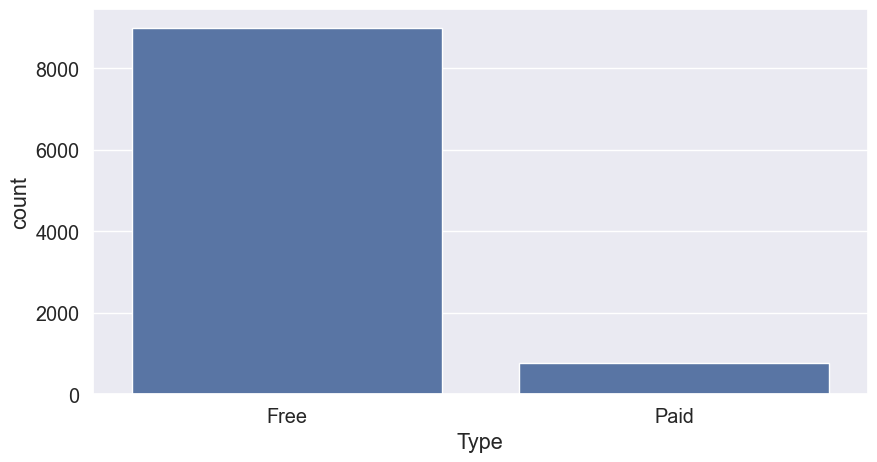

In [61]:
sns.countplot(x=df['Type'])

#### Price

In [62]:
sorted(df['Price'].unique().tolist())

['$0.99',
 '$1.00',
 '$1.04',
 '$1.20',
 '$1.26',
 '$1.29',
 '$1.49',
 '$1.50',
 '$1.59',
 '$1.61',
 '$1.70',
 '$1.75',
 '$1.76',
 '$1.96',
 '$1.97',
 '$1.99',
 '$10.00',
 '$10.99',
 '$109.99',
 '$11.99',
 '$12.99',
 '$13.99',
 '$14.00',
 '$14.99',
 '$15.46',
 '$15.99',
 '$154.99',
 '$16.99',
 '$17.99',
 '$18.99',
 '$19.40',
 '$19.90',
 '$19.99',
 '$2.00',
 '$2.49',
 '$2.50',
 '$2.56',
 '$2.59',
 '$2.60',
 '$2.90',
 '$2.95',
 '$2.99',
 '$200.00',
 '$24.99',
 '$25.99',
 '$28.99',
 '$29.99',
 '$299.99',
 '$3.02',
 '$3.04',
 '$3.08',
 '$3.28',
 '$3.49',
 '$3.61',
 '$3.88',
 '$3.90',
 '$3.95',
 '$3.99',
 '$30.99',
 '$33.99',
 '$37.99',
 '$379.99',
 '$389.99',
 '$39.99',
 '$394.99',
 '$399.99',
 '$4.29',
 '$4.49',
 '$4.59',
 '$4.60',
 '$4.77',
 '$4.80',
 '$4.84',
 '$4.85',
 '$4.99',
 '$400.00',
 '$46.99',
 '$5.00',
 '$5.49',
 '$5.99',
 '$6.49',
 '$6.99',
 '$7.49',
 '$7.99',
 '$74.99',
 '$79.99',
 '$8.49',
 '$8.99',
 '$89.99',
 '$9.00',
 '$9.99',
 '0']

In [63]:
def fix_price(v):
    if v.startswith ('$'):
        return float(v[1:])
    else:
        return float(v)


In [64]:
df['Price']=df['Price'].apply(fix_price)

In [65]:
df['Price'].value_counts()

Price
0.00      9000
0.99       145
2.99       124
1.99        73
4.99        70
          ... 
18.99        1
389.99       1
19.90        1
1.75         1
1.04         1
Name: count, Length: 92, dtype: int64

In [66]:
df['Price'].describe()

count    9758.000000
mean        1.089169
std        16.766892
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

In [67]:
x = df[df['Price'] == 0.0]


In [68]:
x[x['Type'] !='Free']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
8117,Command & Conquer: Rivals,FAMILY,NaN,0.0,NaN,0.0,NaN,0.0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [69]:
df.drop(8117,axis=0,inplace=True)

In [70]:
df.reset_index(drop=True,inplace=True)

#### Content Rating

In [71]:
df['Content Rating'].value_counts(dropna=False)

Content Rating
Everyone           7967
Teen               1057
Mature 17+          393
Everyone 10+        335
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

#### Genres

In [72]:
df['Genres'].unique()

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [73]:
sorted(df['Genres'].unique().tolist())

['Action',
 'Action;Action & Adventure',
 'Adventure',
 'Adventure;Action & Adventure',
 'Adventure;Brain Games',
 'Adventure;Education',
 'Arcade',
 'Arcade;Action & Adventure',
 'Arcade;Pretend Play',
 'Art & Design',
 'Art & Design;Action & Adventure',
 'Art & Design;Creativity',
 'Art & Design;Pretend Play',
 'Auto & Vehicles',
 'Beauty',
 'Board',
 'Board;Action & Adventure',
 'Board;Brain Games',
 'Board;Pretend Play',
 'Books & Reference',
 'Books & Reference;Creativity',
 'Books & Reference;Education',
 'Business',
 'Card',
 'Card;Action & Adventure',
 'Card;Brain Games',
 'Casino',
 'Casual',
 'Casual;Action & Adventure',
 'Casual;Brain Games',
 'Casual;Creativity',
 'Casual;Education',
 'Casual;Music & Video',
 'Casual;Pretend Play',
 'Comics',
 'Comics;Creativity',
 'Communication',
 'Communication;Creativity',
 'Dating',
 'Education',
 'Education;Action & Adventure',
 'Education;Brain Games',
 'Education;Creativity',
 'Education;Education',
 'Education;Music & Video',
 'Edu

In [74]:
df['Genres_temp'] = df['Genres'].apply(lambda r : r.split(';'))

In [75]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Genres_temp
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,5.075174,2.995732,9.210440,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,[Art & Design]
1,Coloring book moana,ART_AND_DESIGN,3.9,6.875232,2.708050,13.122365,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,"[Art & Design, Pretend Play]"
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,11.379520,2.272126,15.424949,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,[Art & Design]
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,12.281389,3.258097,17.727534,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,[Art & Design]
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,6.875232,1.335001,11.512935,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,"[Art & Design, Creativity]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9752,Sya9a Maroc - FR,FAMILY,4.5,3.663562,3.988984,8.517393,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,[Education]
9753,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,1.609438,1.526056,4.615121,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,[Education]
9754,Parkinson Exercices FR,MEDICAL,NaN,1.386294,2.351375,6.908755,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,[Medical]
9755,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,4.744932,NaN,6.908755,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,[Books & Reference]


In [78]:
from sklearn.preprocessing import MultiLabelBinarizer

In [79]:
mlp=MultiLabelBinarizer()
mlp

,classes,None
,sparse_output,False


In [80]:
df_geners=pd.DataFrame(mlp.fit_transform(df['Genres_temp']),columns=mlp.classes_)
df_geners

,Action,Action & Adventure,Adventure,Arcade,Art & Design,Auto & Vehicles,Beauty,Board,Books & Reference,Brain Games,...,Simulation,Social,Sports,Strategy,Tools,Travel & Local,Trivia,Video Players & Editors,Weather,Word
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9752,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9753,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9754,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9755,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [81]:
df_geners.sum().sort_values(ascending=False)

Tools                      830
Education                  659
Entertainment              615
Business                   420
Medical                    400
Personalization            376
Productivity               375
Lifestyle                  370
Finance                    345
Sports                     337
Communication              317
Action                     313
Health & Fitness           290
Photography                283
News & Magazines           254
Social                     239
Casual                     235
Books & Reference          225
Travel & Local             219
Simulation                 213
Shopping                   203
Arcade                     200
Dating                     171
Video Players & Editors    168
Puzzle                     146
Maps & Navigation          131
Role Playing               118
Food & Drink               113
Racing                     108
Action & Adventure         105
Strategy                   103
Educational                102
Auto & V

In [82]:
sorted(df['Last Updated'].unique().tolist())

['April 1, 2016',
 'April 1, 2017',
 'April 1, 2018',
 'April 10, 2013',
 'April 10, 2014',
 'April 10, 2015',
 'April 10, 2016',
 'April 10, 2017',
 'April 10, 2018',
 'April 11, 2011',
 'April 11, 2014',
 'April 11, 2016',
 'April 11, 2017',
 'April 11, 2018',
 'April 12, 2016',
 'April 12, 2017',
 'April 12, 2018',
 'April 13, 2014',
 'April 13, 2016',
 'April 13, 2017',
 'April 13, 2018',
 'April 14, 2015',
 'April 14, 2016',
 'April 14, 2017',
 'April 14, 2018',
 'April 15, 2015',
 'April 15, 2016',
 'April 15, 2017',
 'April 15, 2018',
 'April 16, 2011',
 'April 16, 2017',
 'April 16, 2018',
 'April 17, 2014',
 'April 17, 2016',
 'April 17, 2017',
 'April 17, 2018',
 'April 18, 2011',
 'April 18, 2017',
 'April 18, 2018',
 'April 19, 2016',
 'April 19, 2017',
 'April 19, 2018',
 'April 2, 2015',
 'April 2, 2016',
 'April 2, 2017',
 'April 2, 2018',
 'April 20, 2015',
 'April 20, 2016',
 'April 20, 2017',
 'April 20, 2018',
 'April 21, 2016',
 'April 21, 2017',
 'April 21, 2018',


#### 

In [83]:
df['Last Updated']=pd.to_datetime(df['Last Updated'],errors='coerce',format='%B %d, %Y')

In [84]:
df['Last Updated']

0      2018-01-07
1      2018-01-15
2      2018-08-01
3      2018-06-08
4      2018-06-20
          ...    
9752   2017-07-25
9753   2018-07-06
9754   2017-01-20
9755   2015-01-19
9756   2018-07-25
Name: Last Updated, Length: 9757, dtype: datetime64[ns]

In [85]:
df['Year Updated'] = df['Last Updated'].dt.year
df['Month Updated'] = df['Last Updated'].dt.month_name()
df['Day Updated'] = df['Last Updated'].dt.day_name()

In [86]:
df.drop(['Current Ver','Android Ver'],axis=1,inplace=True)

In [87]:
df.drop('Genres_temp', axis=1).duplicated().sum()

0

In [88]:
df.isnull().sum()

App                  0
Category             0
Rating            1464
Reviews              0
Size              1250
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Genres_temp          0
Year Updated         0
Month Updated        0
Day Updated          0
dtype: int64

In [89]:
df.isnull().mean()*100


App                0.000000
Category           0.000000
Rating            15.004612
Reviews            0.000000
Size              12.811315
Installs           0.000000
Type               0.000000
Price              0.000000
Content Rating     0.000000
Genres             0.000000
Last Updated       0.000000
Genres_temp        0.000000
Year Updated       0.000000
Month Updated      0.000000
Day Updated        0.000000
dtype: float64

In [90]:
df.drop("Genres_temp", axis=1, inplace=True)

<Axes: >

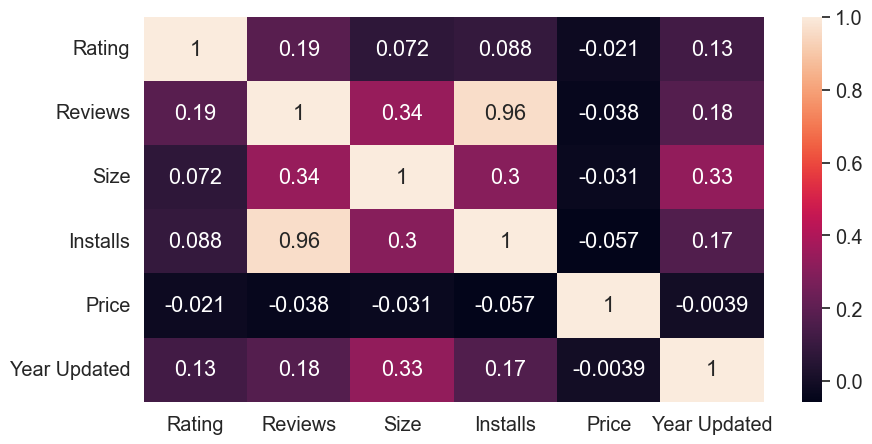

In [92]:

sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='Rating', ylabel='Size'>

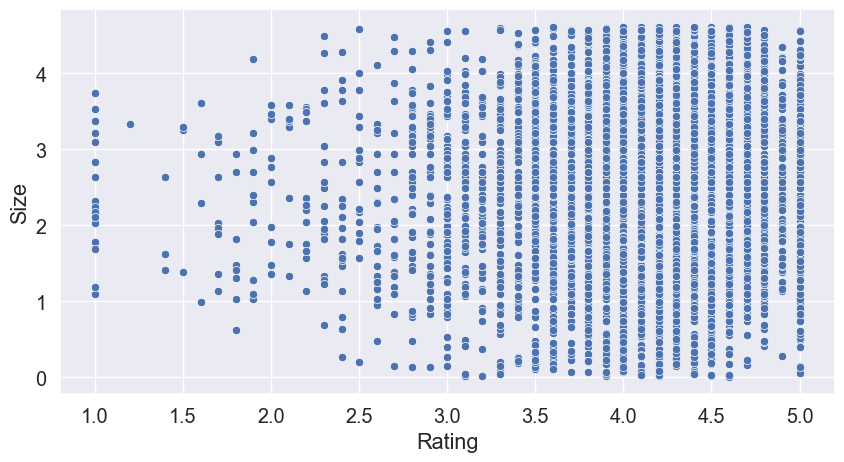

In [93]:
sns.scatterplot(x=df["Rating"], y=df["Size"]) #num. vs num.

<Axes: xlabel='Content Rating', ylabel='Size'>

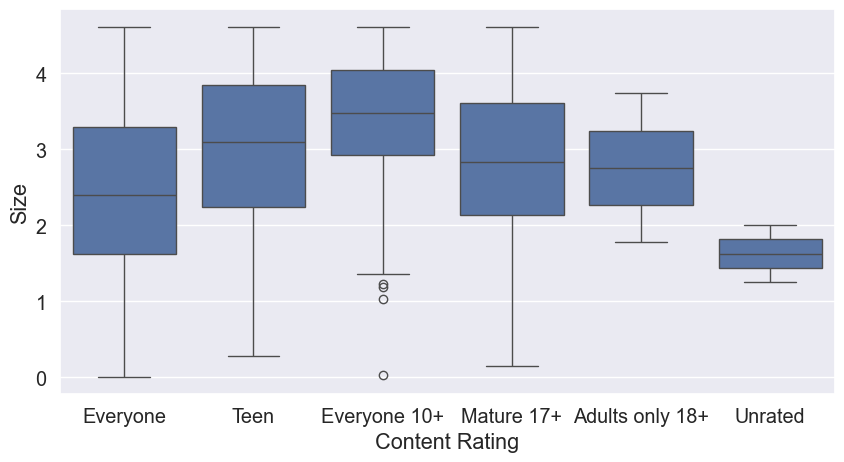

In [94]:
sns.boxplot(x=df["Content Rating"], y=df["Size"]) #cat. vs num.

<Axes: xlabel='Content Rating', ylabel='count'>

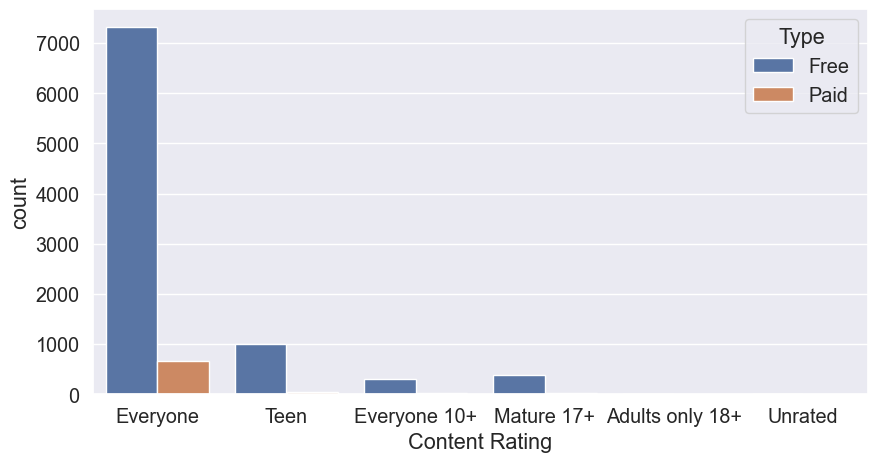

In [95]:
sns.countplot(x=df["Content Rating"], hue=df["Type"]) #cat. vs cat.

### Questions:

#### - What is the most expensive app on the store ?

In [96]:
df[df['Price'] == df['Price'].max()]['App']

3523    I'm Rich - Trump Edition
Name: App, dtype: object

#### - Which Category has more apps ?

In [97]:
df['Category'].value_counts().head(1)

Category
FAMILY    1908
Name: count, dtype: int64

#### - What is the average size of the free apps & paid apps? 

In [98]:
df.groupby('Type')['Size'].mean()

Type
Free    2.577182
Paid    2.343991
Name: Size, dtype: float64

<Axes: xlabel='Type', ylabel='Size'>

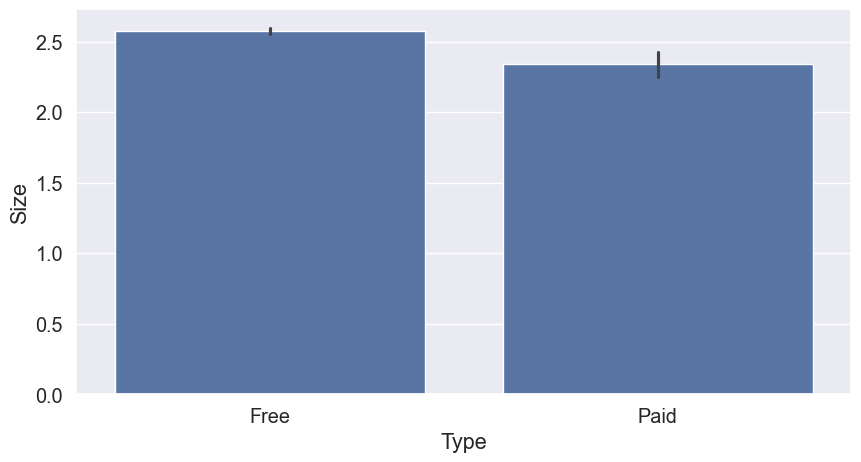

In [99]:
sns.barplot(x=df["Type"], y=df["Size"])

#### - What is the 5 top Installs apps that has rate of 5 ?

In [100]:
tempp = df[df['Rating'] == 5].sort_values(by= 'Installs', ascending=False).head()
list(tempp["App"].values)

['Ek Bander Ne Kholi Dukan',
 'Superheroes, Marvel, DC, Comics, TV, Movies News',
 'CL Keyboard - Myanmar Keyboard (No Ads)',
 'Oración CX',
 'Hojiboy Tojiboyev Life Hacks']

#### - How many apps that has more than 50K reviews?

In [101]:
df[df['Reviews']>50000].shape[0]

0

#### - What is the average size of the apps for each category with each type?

In [102]:
pd.pivot_table(data=df, index="Category", columns="Type", values="Size")

Type,Free,Paid
Category,,
ART_AND_DESIGN,2.358118,1.756639
AUTO_AND_VEHICLES,2.575740,2.861793
BEAUTY,2.367265,NaN
BOOKS_AND_REFERENCE,2.232690,2.196686
BUSINESS,2.291284,2.247855
COMICS,2.400250,NaN
COMMUNICATION,2.106510,1.276350
DATING,2.531722,1.742972
EDUCATION,2.542067,3.600824


In [103]:
px.imshow(pd.pivot_table(data=df, index="Category", columns="Type", values="Size"))

<Axes: xlabel='Type', ylabel='Category'>

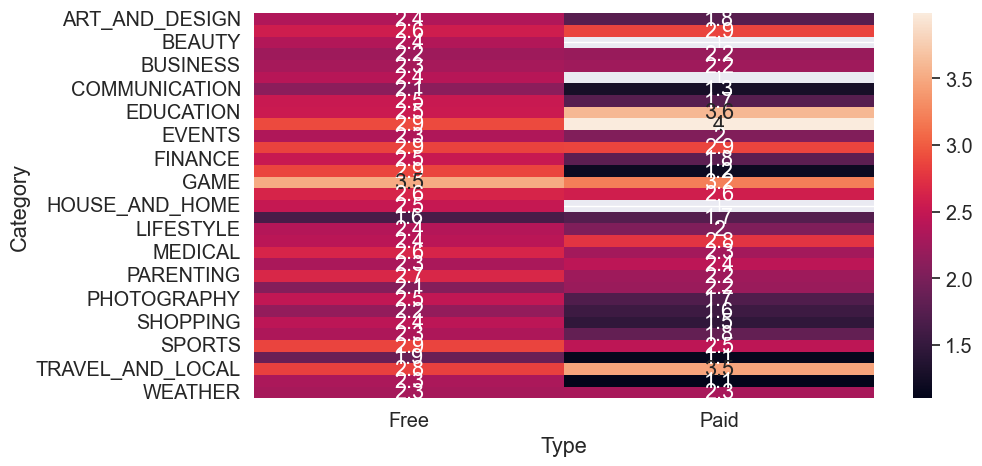

In [104]:
sns.heatmap(pd.pivot_table(data=df, index="Category", columns="Type", values="Size"), annot=True)

#### - How many apps have rating > 4.7 ,not free and what is thier avg number of reviews ? 

In [105]:
df[(df['Rating'] > 4.7) & (df['Type'] == 'Paid')]['Reviews'].count()

70

In [106]:
df[(df['Rating'] > 4.7) & (df['Type'] == 'Paid')]['Reviews'].mean()

3.8238564469727474

#### - is there a correlation between rating and Reviews ?

In [107]:
df[['Rating', 'Reviews']].corr()

,Rating,Reviews
Rating,1.0000,0.1858
Reviews,0.1858,1.0000


In [108]:
px.scatter(data_frame=df, x='Reviews', y='Rating')

#### - How many apps for each type for each Content Rating?

In [109]:
pd.pivot_table(data=df, index='Type', columns='Content Rating', values='Reviews',aggfunc='count')

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
Type,,,,,,
Free,3.0,7310.0,304.0,375.0,1005.0,2.0
Paid,NaN,657.0,31.0,18.0,52.0,NaN


In [110]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Year Updated,Month Updated,Day Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,5.075174,2.995732,9.210440,Free,0.0,Everyone,Art & Design,2018-01-07,2018,January,Sunday
1,Coloring book moana,ART_AND_DESIGN,3.9,6.875232,2.708050,13.122365,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2018,January,Monday
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,11.379520,2.272126,15.424949,Free,0.0,Everyone,Art & Design,2018-08-01,2018,August,Wednesday
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,12.281389,3.258097,17.727534,Free,0.0,Teen,Art & Design,2018-06-08,2018,June,Friday
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,6.875232,1.335001,11.512935,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,2018,June,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9752,Sya9a Maroc - FR,FAMILY,4.5,3.663562,3.988984,8.517393,Free,0.0,Everyone,Education,2017-07-25,2017,July,Tuesday
9753,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,1.609438,1.526056,4.615121,Free,0.0,Everyone,Education,2018-07-06,2018,July,Friday
9754,Parkinson Exercices FR,MEDICAL,NaN,1.386294,2.351375,6.908755,Free,0.0,Everyone,Medical,2017-01-20,2017,January,Friday
9755,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,4.744932,NaN,6.908755,Free,0.0,Mature 17+,Books & Reference,2015-01-19,2015,January,Monday
